In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Dataset Loading

In [2]:
df =pd.read_csv('project1_internship_retention.csv')
df

,Intern_ID,Department,Internship_Duration_Weeks,Feedback_Score,Supervisor_Rating,Commute_Distance_km,Monthly_Stipend_XAF,Remote_Work_Option,Returned
0,INT-00001,Admin,7,9.4,7.3,2.1,150000,No,Yes
1,INT-00002,Marketing,21,7.4,7.5,3.1,75000,Yes,Yes
2,INT-00003,Engineering,8,6.1,7.2,16.7,0,No,No
3,INT-00004,Engineering,19,6.2,7.2,14.7,0,Yes,No
4,INT-00005,IT,17,6.8,4.8,13.0,25000,No,No
...,...,...,...,...,...,...,...,...,...
9995,INT-09996,Finance,20,8.7,5.7,9.0,50000,Yes,Yes
9996,INT-09997,Finance,8,5.2,5.0,6.0,75000,Yes,No
9997,INT-09998,Marketing,20,8.0,8.1,4.8,25000,Yes,Yes
9998,INT-09999,Admin,4,9.3,6.7,5.9,0,No,Yes


In [3]:
print(df['Department'].value_counts())

Department
IT             3053
Engineering    2511
Admin          2023
Finance        1452
Marketing       961
Name: count, dtype: int64


In [4]:
print(df['Feedback_Score'].value_counts())

Feedback_Score
7.8    312
8.1    295
7.9    286
8.2    286
8.0    278
      ... 
2.5      1
2.0      1
1.7      1
2.3      1
2.2      1
Name: count, Length: 80, dtype: int64


# Removing the conflict Column

In [5]:
data = df.drop(df.columns[[0, 4, 6, 7]], axis=1)
data

,Department,Internship_Duration_Weeks,Feedback_Score,Commute_Distance_km,Returned
0,Admin,7,9.4,2.1,Yes
1,Marketing,21,7.4,3.1,Yes
2,Engineering,8,6.1,16.7,No
3,Engineering,19,6.2,14.7,No
4,IT,17,6.8,13.0,No
...,...,...,...,...,...
9995,Finance,20,8.7,9.0,Yes
9996,Finance,8,5.2,6.0,No
9997,Marketing,20,8.0,4.8,Yes
9998,Admin,4,9.3,5.9,Yes


In [6]:
data.isna().sum()

Department                   0
Internship_Duration_Weeks    0
Feedback_Score               0
Commute_Distance_km          0
Returned                     0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Department                 10000 non-null  object 
 1   Internship_Duration_Weeks  10000 non-null  int64  
 2   Feedback_Score             10000 non-null  float64
 3   Commute_Distance_km        10000 non-null  float64
 4   Returned                   10000 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 390.8+ KB


# Data groups checking (unique difference)

In [8]:
print(data['Department'].unique())

['Admin' 'Marketing' 'Engineering' 'IT' 'Finance']


# data Mapping (strings to int)

In [9]:
data['Department'] = data['Department'].map({'Admin':0, 'Marketing':1, 'Engineering':2, 'IT':3, 'Finance':4})
data
#data = pd.DataFrame({
    #"Department": ["Admin", "Marketing", "Engineering", "IT", "Finance"]
#})

# 1. Fit the encoder


,Department,Internship_Duration_Weeks,Feedback_Score,Commute_Distance_km,Returned
0,0,7,9.4,2.1,Yes
1,1,21,7.4,3.1,Yes
2,2,8,6.1,16.7,No
3,2,19,6.2,14.7,No
4,3,17,6.8,13.0,No
...,...,...,...,...,...
9995,4,20,8.7,9.0,Yes
9996,4,8,5.2,6.0,No
9997,1,20,8.0,4.8,Yes
9998,0,4,9.3,5.9,Yes


In [10]:
#encoder = LabelEncoder()
#data2=data["Department_encoded"] = encoder.fit_transform(data["Department"])
#data2

In [11]:
#data['Remote_Work_Option'] = data['Remote_Work_Option'].map({'Yes':1, 'No':0})
#data

In [12]:
#data = pd.DataFrame({
 #   "Returned": ["Yes", "No",]
#})

In [13]:
#encoder = LabelEncoder()
#data1=data["Returned_encoded"] = encoder.fit_transform(data["Returned"])
#data1

In [14]:
data['Returned'] = data['Returned'].map({'Yes':1, 'No':0})
data

,Department,Internship_Duration_Weeks,Feedback_Score,Commute_Distance_km,Returned
0,0,7,9.4,2.1,1
1,1,21,7.4,3.1,1
2,2,8,6.1,16.7,0
3,2,19,6.2,14.7,0
4,3,17,6.8,13.0,0
...,...,...,...,...,...
9995,4,20,8.7,9.0,1
9996,4,8,5.2,6.0,0
9997,1,20,8.0,4.8,1
9998,0,4,9.3,5.9,1


In [15]:
data.isnull().sum()

Department                   0
Internship_Duration_Weeks    0
Feedback_Score               0
Commute_Distance_km          0
Returned                     0
dtype: int64

In [16]:
data.shape

(10000, 5)

In [17]:
target_col = ['Department','Internship_Duration_Weeks','Feedback_Score','Commute_Distance_km','Returned']

print(df[target_col].value_counts())

Department   Internship_Duration_Weeks  Feedback_Score  Commute_Distance_km  Returned
IT           14                         7.3             12.2                 Yes         2
Engineering  23                         8.9             0.7                  Yes         2
IT           18                         7.9             1.5                  Yes         2
                                        7.5             3.1                  Yes         2
Admin        22                         9.5             2.8                  Yes         2
                                                                                        ..
Engineering  15                         5.8             2.3                  Yes         1
                                        5.9             1.2                  Yes         1
                                                        10.1                 Yes         1
                                                        18.7                 No          1
Mark

In [18]:
data.head()

,Department,Internship_Duration_Weeks,Feedback_Score,Commute_Distance_km,Returned
0,0,7,9.4,2.1,1
1,1,21,7.4,3.1,1
2,2,8,6.1,16.7,0
3,2,19,6.2,14.7,0
4,3,17,6.8,13.0,0


# Dropping the predict data/column for model testing

In [19]:
x = data.drop('Returned', axis=1)
y = data['Returned']

In [20]:
x.to_csv("x.csv", index=False)

In [21]:
x.head()

,Department,Internship_Duration_Weeks,Feedback_Score,Commute_Distance_km
0,0,7,9.4,2.1
1,1,21,7.4,3.1
2,2,8,6.1,16.7
3,2,19,6.2,14.7
4,3,17,6.8,13.0


In [23]:
y.head()

0    1
1    1
2    0
3    0
4    0
Name: Returned, dtype: int64

# Assigning and slpiting of model Training Data

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [26]:
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Testing Level and ploting of metrix for visualization

In [27]:
y_pred = model.predict(x_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.784

Confusion Matrix:
 [[ 276  328]
 [ 104 1292]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.46      0.56       604
           1       0.80      0.93      0.86      1396

    accuracy                           0.78      2000
   macro avg       0.76      0.69      0.71      2000
weighted avg       0.78      0.78      0.77      2000



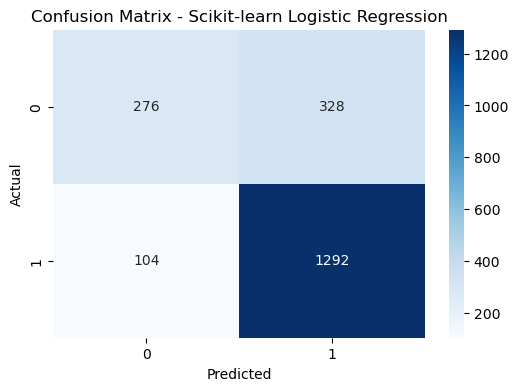

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Scikit-learn Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [29]:
joblib.dump(model, 'intern.joblib')

['intern.joblib']

In [30]:
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

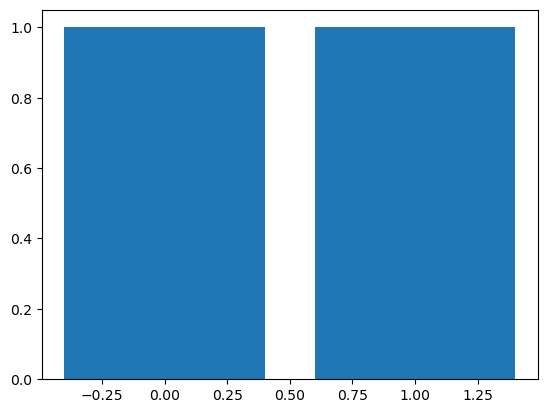

In [31]:
plt.bar(y_test, y_pred)
plt.show()

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.46      0.56       604
           1       0.80      0.93      0.86      1396

    accuracy                           0.78      2000
   macro avg       0.76      0.69      0.71      2000
weighted avg       0.78      0.78      0.77      2000

